In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math
import copy
import pandas as pd

np.set_printoptions(precision = 2, suppress=True)

In [7]:
speed = np.array([530, 1325, 1302, 1302, 1260, 396, 477, 703, 530, 297, 787, 1283, 1178, 536, 1573, 639, 1659, 1081, 1746, 703, 716, 1623, 209, 1667, 493, 1540, 664, 321, 1134, 402, 989, 1776, 736, 1249, 730, 933, 417, 911, 1409, 1306, 438, 1257, 702, 1174, 352, 1167, 1450, 546])
feed = np.array([0.503, 0.108, 0.427, 0.456, 0.834, 0.358, 0.438, 0.452, 0.318, 0.486, 0.178, 0.257, 0.799, 0.170, 0.597, 0.327, 0.850, 0.883, 0.808, 0.547, 0.547, 0.180, 0.156, 0.128, 0.219, 0.546, 0.678, 0.191, 0.692, 0.697, 0.164, 0.644, 0.710, 0.382, 0.729, 0.175, 0.282, 0.290, 0.210, 0.241, 0.648, 0.561, 0.228, 0.711, 0.691, 0.431, 0.509, 0.644])
y_train = np.array([1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1])
df = pd.DataFrame({"speed": speed, "feed": feed, "class": y_train})
df

,speed,feed,class
0,530,0.503,1
1,1325,0.108,0
2,1302,0.427,0
3,1302,0.456,0
4,1260,0.834,1
5,396,0.358,0
6,477,0.438,0
7,703,0.452,0
8,530,0.318,1
9,297,0.486,0


In [10]:
# checking if y is balanced or not
print(f"y_train: {y_train.mean()}, {1 - y_train.mean()}")

y_train: 0.2708333333333333, 0.7291666666666667


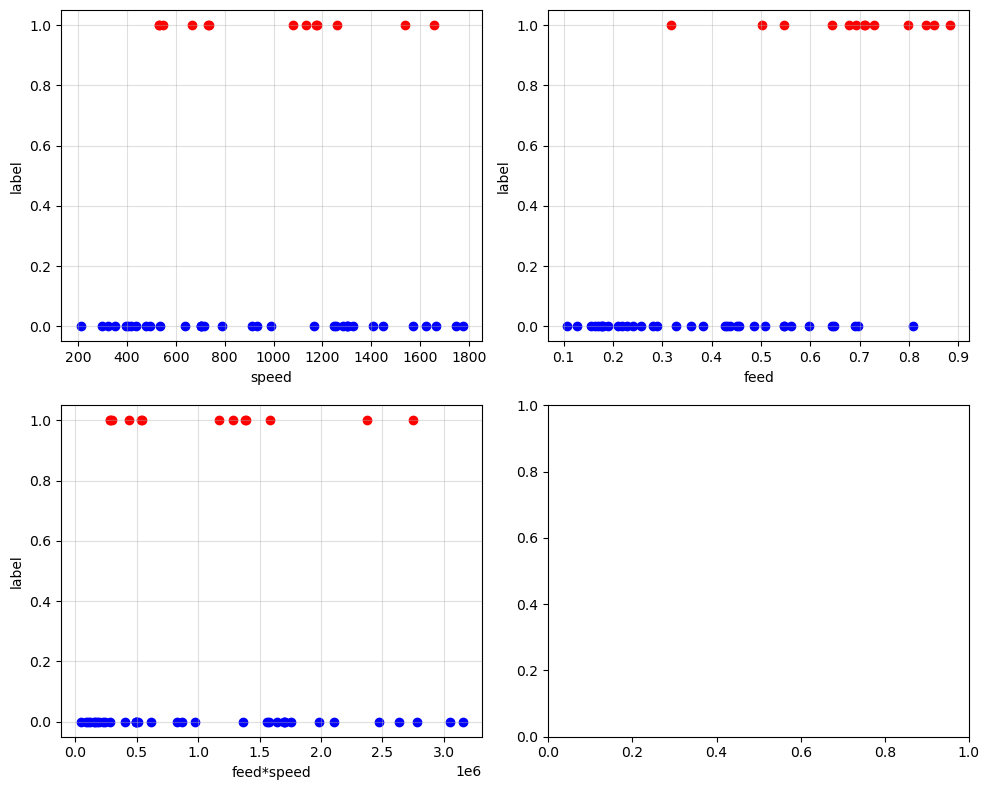

In [45]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

ax[0, 0].scatter(speed[y_train == 1], y_train[y_train == 1], marker = "o", color="r")
ax[0, 0].scatter(speed[y_train == 0], y_train[y_train == 0], marker = "o", color="b")
ax[0, 0].set_xlabel("speed")
ax[0, 0].set_ylabel("label")
ax[0, 0].grid(alpha=0.4)


ax[0, 1].scatter(feed[y_train == 1], y_train[y_train == 1], marker = "o", color="r")
ax[0, 1].scatter(feed[y_train == 0], y_train[y_train == 0], marker = "o", color="b")
ax[0, 1].set_xlabel("feed")
ax[0, 1].set_ylabel("label")
ax[0, 1].grid(alpha=0.4)

ax[1, 0].scatter(speed[y_train == 1]**2, y_train[y_train == 1], marker = "o", color="r")
ax[1, 0].scatter(speed[y_train == 0]**2, y_train[y_train == 0], marker = "o", color="b")
ax[1, 0].set_xlabel("feed*speed")
ax[1, 0].set_ylabel("label")
ax[1, 0].grid(alpha=0.4)


plt.tight_layout()
plt.show()

In [49]:
x_train = np.array([speed, feed, speed**2])
x_train = x_train.T
# x_train.shape
np.ptp(x_train, axis=0) ## needs scaling

array([   1567.  ,       0.78, 3110495.  ])

In [50]:
def z_scaling(x):
    mean = x.mean(axis = 0)
    sigma = x.std(axis = 0)

    x = (x - mean) / sigma

    return mean, sigma, x

In [52]:
mean,sigma, x_scaled = z_scaling(x_train)
np.ptp(x_scaled, axis=0) # now it's scaled

array([3.5 , 3.42, 3.45])

In [54]:
def predict(x, w, b):
    z = x @ w + b
    g = 1 / (1 + np.exp(-z))

    return g

In [57]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    fx = predict(x, w, b)
    cost = (-y * np.log(fx)) - ((1 - y)*(np.log(1 - fx)))
    cost = cost.sum() / m

    return cost

In [58]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    err = predict(x, w, b) - y
    dj_dw = err @ x
    dj_db = err.sum()

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [61]:
def gradient_descent(x, y, w_init, b_init, alpha, iterations, threshold):
    cost = []
    w = w_init
    b = b_init
    
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        cost.append(compute_cost(x, y, w, b))

        if all(abs(dj_dw) < threshold) and abs(dj_db) < threshold:
            print(f"iterations: {i}, cost: {cost[-1]}")
            break

        if i % math.ceil(iterations / 10) == 0:
            print(f"iteration: {i}, cost: {cost[-1]}")

    return cost, w, b

In [67]:
alpha = np.array([0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3])
threshold = 0.001
iterations = 1000
w = np.array([0, 0, 0])
b = 0

for i in range(len(alpha)):
    print(f"learning rate: {alpha[i]}")
    cost, final_w, final_b = gradient_descent(x_scaled, y_train, w, b, alpha[i], iterations, threshold)



learning rate: 0.001
iteration: 0, cost: 0.6930224320754359
iteration: 100, cost: 0.6808604082496671
iteration: 200, cost: 0.6692962861814508
iteration: 300, cost: 0.6582987470426305
iteration: 400, cost: 0.6478376606915627
iteration: 500, cost: 0.6378841397315775
iteration: 600, cost: 0.6284105722162577
iteration: 700, cost: 0.6193906360472693
iteration: 800, cost: 0.610799297946527
iteration: 900, cost: 0.6026127996672284
learning rate: 0.003
iteration: 0, cost: 0.6927730296681363
iteration: 100, cost: 0.658076216638208
iteration: 200, cost: 0.628211967442898
iteration: 300, cost: 0.6024353208449447
iteration: 400, cost: 0.5801044004288681
iteration: 500, cost: 0.5606753759463222
iteration: 600, cost: 0.5436924815253937
iteration: 700, cost: 0.5287762266707489
iteration: 800, cost: 0.5156116505500342
iteration: 900, cost: 0.503937568701538
learning rate: 0.01
iteration: 0, cost: 0.6919011141391325
iteration: 100, cost: 0.594039811008226
iteration: 200, cost: 0.533119917875121
iterati

In [68]:
cost, final_w, final_b = gradient_descent(x_scaled, y_train, w, b, alpha[i], iterations, threshold)


iteration: 0, cost: 0.44895215183973897
iteration: 100, cost: 0.3283285604816721
iteration: 200, cost: 0.3181777229602482
iteration: 300, cost: 0.3144164235279199
iteration: 400, cost: 0.3128850766313978
iterations: 461, cost: 0.3124202346510972


In [78]:
predictions = (predict(x_scaled, final_w, final_b) >= 0.5).astype(int)
score = (predictions == y_train).mean() * 100
score


np.float64(93.75)

In [93]:
x_final = np.array([[900, 0.45, 900**2]])
x_final = (x_final - mean)/sigma
x_final

array([[-0.11, -0.04, -0.33]])

In [96]:
final_prediction = (predict(x_final, final_w, final_b) >= 0.5).astype(int)
print(f"{final_prediction[0]}")

0


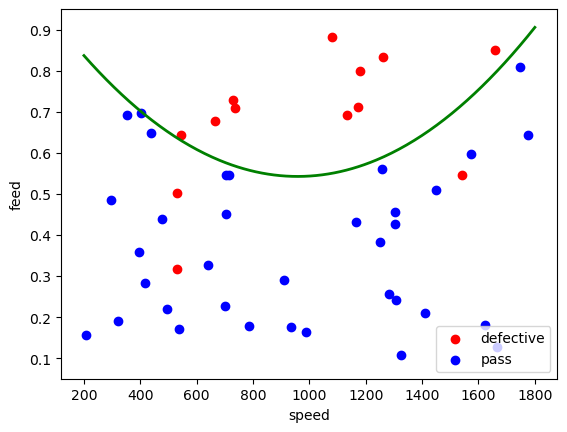

In [104]:
plt.scatter(x_train[y_train == 1, 0], x_train[y_train == 1, 1], marker="o", color="r", label="defective")
plt.scatter(x_train[y_train == 0, 0], x_train[y_train == 0, 1], marker="o", color="b", label="pass")

# boundary: build the grid in RAW units, then scale it the same way as training data
s_grid = np.linspace(200, 1800, 300)
grid = np.column_stack([s_grid, np.zeros(300), s_grid**2])   # feed column is a placeholder
grid_scaled = (grid - mean) / sigma

s_sc = grid_scaled[:, 0]
s2_sc = grid_scaled[:, 2]
f_sc = -(final_w[0]*s_sc + final_w[2]*s2_sc + final_b) / final_w[1]

f_raw = f_sc * sigma[1] + mean[1]        # unscale the feed values back

plt.plot(s_grid, f_raw, color="g", lw=2)
plt.ylim(0.05, 0.95)
plt.xlabel("speed")
plt.ylabel("feed")
plt.legend()
plt.show()